In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from torchvision import datasets, transforms
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
# Download FashionMNIST Dataset
from tensorflow import keras
fashion = keras.datasets.fashion_mnist
(xtrain, ytrain), (xtest, ytest) = fashion.load_data()

29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Image Label : 5


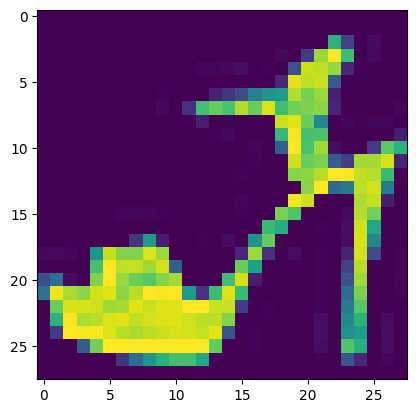

In [3]:
imgIndex = 9
image = xtrain[imgIndex]
print("Image Label :",ytrain[imgIndex])
plt.imshow(image)

In [4]:
print(xtrain.shape)
print(xtest.shape)

(60000, 28, 28)
(10000, 28, 28)


In [6]:
# Initialize model, loss Function and optimizer
model = nn.Sequential(
    nn.Flatten(),
    nn.Linear(784, 128),
    nn.ReLU(),
    nn.Linear(128, 64),
    nn.ReLU(),
    nn.Linear(64, 10)
)

loss_fn = nn.BCELoss()# Because of CrossEntropy, we don't use softmax at the final layer
optimizer = optim.Adam(model.parameters(), lr=0.001)

In [7]:
batch_size = 64

# Convert numpy arrays to torch tensors
X_train_tensor = torch.tensor(xtrain, dtype=torch.float32).unsqueeze(1) / 255.0 # Add channel dimension and normalize
Y_train_tensor = torch.tensor(ytrain, dtype=torch.long)
X_test_tensor = torch.tensor(xtest, dtype=torch.float32).unsqueeze(1) / 255.0 # Add channel dimension and normalize
Y_test_tensor = torch.tensor(ytest, dtype=torch.long)

# Create TensorDatasets
train_dataset = TensorDataset(X_train_tensor, Y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, Y_test_tensor)

# Create DataLoaders
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

print("DataLoaders created.")

DataLoaders created.


In [8]:
loss_fn = nn.CrossEntropyLoss() # Change to CrossEntropyLoss for multi-class classification

# Training function
def train_model(model, train_loader, loss_fn, optimizer, device):
    model.train()
    running_loss = 0.0
    for inputs, labels in train_loader:
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = loss_fn(outputs, labels)
        loss.backward()
        optimizer.step()
        running_loss += loss.item() * inputs.size(0)
    return running_loss / len(train_loader.dataset)

# Evaluation function
def evaluate_model(model, test_loader, loss_fn, device):
    model.eval()
    running_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            outputs = model(inputs)
            loss = loss_fn(outputs, labels)
            running_loss += loss.item() * inputs.size(0)
            _, predicted = torch.max(outputs.data, 1)
            total += labels.size(0)
            correct += (predicted == labels).sum().item()
    accuracy = 100 * correct / total
    return running_loss / len(test_loader.dataset), accuracy

print("Training and evaluation functions defined.")

Training and evaluation functions defined.


In [9]:
num_epochs = 10
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model.to(device)

print(f"Training on: {device}")

for epoch in range(num_epochs):
    train_loss = train_model(model, train_loader, loss_fn, optimizer, device)
    test_loss, test_accuracy = evaluate_model(model, test_loader, loss_fn, device)
    print(f'Epoch {epoch+1}/{num_epochs}, Train Loss: {train_loss:.4f}, Test Loss: {test_loss:.4f}, Test Accuracy: {test_accuracy:.2f}%')

Training on: cuda
Epoch 1/10, Train Loss: 0.5635, Test Loss: 0.4351, Test Accuracy: 84.70%
Epoch 2/10, Train Loss: 0.3952, Test Loss: 0.4324, Test Accuracy: 84.43%
Epoch 3/10, Train Loss: 0.3509, Test Loss: 0.3761, Test Accuracy: 86.60%
Epoch 4/10, Train Loss: 0.3261, Test Loss: 0.3777, Test Accuracy: 86.37%
Epoch 5/10, Train Loss: 0.3061, Test Loss: 0.3545, Test Accuracy: 87.26%
Epoch 6/10, Train Loss: 0.2882, Test Loss: 0.3551, Test Accuracy: 87.20%
Epoch 7/10, Train Loss: 0.2803, Test Loss: 0.3540, Test Accuracy: 87.12%
Epoch 8/10, Train Loss: 0.2665, Test Loss: 0.3413, Test Accuracy: 87.60%
Epoch 9/10, Train Loss: 0.2562, Test Loss: 0.3432, Test Accuracy: 88.05%
Epoch 10/10, Train Loss: 0.2468, Test Loss: 0.3352, Test Accuracy: 88.35%
